In [1]:
import moocore
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import moocore

In [2]:
df = pd.read_csv('results.csv')
df

,model,datasets,fold,hit_rate,ndcg,mrr
0,bpr_pure,amazon,0,0.286319,0.173250,0.155317
1,bpr_pure,amazon,1,0.309984,0.190472,0.170022
2,bpr_pure,amazon,2,0.308972,0.190988,0.170490
3,bpr_pure,amazon,3,0.306447,0.189243,0.169644
4,bpr_pure,amazon,4,0.297218,0.184428,0.167026
5,bpr_pure,imdb,0,0.162351,0.090910,0.092270
6,bpr_pure,imdb,1,0.158572,0.085710,0.087101
7,bpr_pure,imdb,2,0.153114,0.082476,0.082910
8,bpr_pure,imdb,3,0.158852,0.086444,0.087926
9,bpr_pure,imdb,4,0.188383,0.100750,0.099462


--- Teste de Normalidade (Global) ---
Shapiro-Wilk: p-value = 7.6025e-09 (Não-Normal)

Número de blocos (Dataset + Folds) analisados: 15
Modelos comparados: ['bpr_pure', 'contrastive', 'hybrid']

--- Teste de Friedman (Todos os Datasets) ---
Estatística: 9.7333
p-value: 7.6990e-03

--- Ranking Médio Global ---
model
hybrid         1.400000
bpr_pure       2.066667
contrastive    2.533333
dtype: float64 



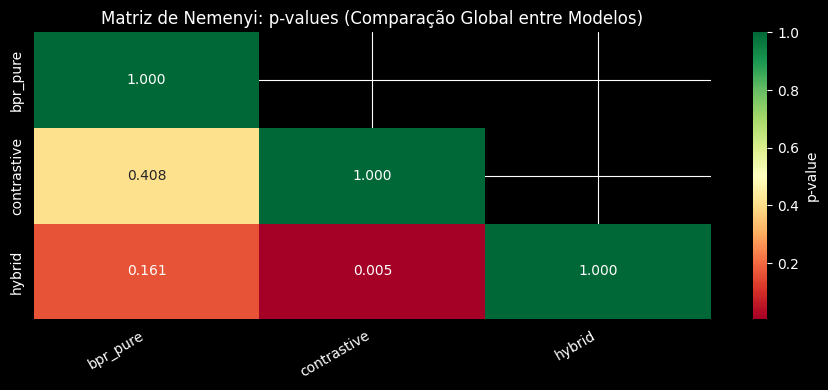

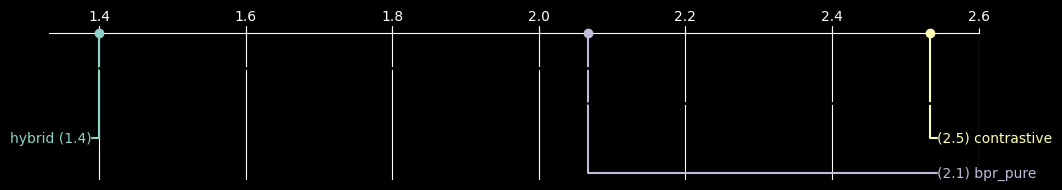

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, friedmanchisquare
import scikit_posthocs as sp




# Cálculo do Hypervolume (Produto das métricas de maximização)
def calculate_hv(row):
    ref_point = np.array([0.0, 0.0, 0.0]) # [hr@10, ndcg@10, mrr]
    ind = moocore.Hypervolume(ref=ref_point, maximise=True)
    return ind(np.array([[row['hit_rate'], row['ndcg'], row['mrr']]]))

df['HV'] = df.apply(calculate_hv, axis=1)

# 2. Teste de Normalidade Global (Shapiro-Wilk)
stat, p_norm = shapiro(df['HV'])
print(f"--- Teste de Normalidade (Global) ---")
print(f"Shapiro-Wilk: p-value = {p_norm:.4e} ({'Normal' if p_norm > 0.05 else 'Não-Normal'})\n")

# 3. Preparação da Matriz de Friedman (Considerando Todos os Datasets)
# Criamos uma chave única combinando Dataset e Fold para serem nossos 'blocos'
df['block'] = df['datasets'] + "_f" + df['fold'].astype(str)

# Pivotamos: Linhas são as combinações Dataset/Fold, Colunas são os Modelos
pivot_df = df.pivot_table(index='block', columns='model', values='HV')

# O Friedman exige que não haja NaNs. Vamos remover blocos onde nem todos os modelos rodaram
pivot_df = pivot_df.dropna()

print(f"Número de blocos (Dataset + Folds) analisados: {len(pivot_df)}")
print(f"Modelos comparados: {list(pivot_df.columns)}\n")

# 4. Teste de Friedman
stat_f, p_f = friedmanchisquare(*[pivot_df[col] for col in pivot_df.columns])
print(f"--- Teste de Friedman (Todos os Datasets) ---")
print(f"Estatística: {stat_f:.4f}")
print(f"p-value: {p_f:.4e}\n")

# 5. Post-hoc Nemenyi e Visualizações
if p_f < 0.05:
    # Detalhamento do Rank (Maiores valores de HV recebem os melhores postos)
    # rank(ascending=False) garante que o maior HV seja rank 1
    ranks = pivot_df.rank(axis=1, ascending=False).mean().sort_values()
    print("--- Ranking Médio Global ---")
    print(ranks, "\n")

    # Cálculo da Matriz de Nemenyi
    nemenyi_matrix = sp.posthoc_nemenyi_friedman(pivot_df)

    # PLOT 1: Mapa de Calor da Matriz de Nemenyi
    plt.figure(figsize=(9, 4))
    # plt.style.use('default')
    sns.heatmap(nemenyi_matrix, annot=True, cmap='RdYlGn', fmt=".3f",
                cbar_kws={'label': 'p-value'}, mask=np.triu(np.ones_like(nemenyi_matrix, dtype=bool), k=1))
    plt.title('Matriz de Nemenyi: p-values (Comparação Global entre Modelos)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('matriz_nemenyi.png', dpi=300)
    plt.show()

    # PLOT 2: Gráfico de Diferença Crítica (CD Diagram)
    # Este gráfico é o mais importante para visualizar a performance entre datasets
    plt.figure(figsize=(12, 2))
    sp.critical_difference_diagram(ranks, nemenyi_matrix)
    #plt.title("Diagrama de Diferença Crítica (CD) - Todos os Datasets")
    plt.savefig('diagrama_dc.png', dpi=300)
    plt.show()
else:
    print("O teste de Friedman não encontrou diferenças significativas entre os modelos considerando todos os datasets.")

In [4]:
import pandas as pd
import copy
# 1. Carregar os arquivos
# pivot_df = copy.deepcopy(pivot_df)
ranks_df = pivot_df.rank(axis=1, ascending=False)

# Limpeza: Remover possíveis '\n' nos nomes das colunas que vêm do CSV
pivot_df.columns = pivot_df.columns.str.replace('\n', '', regex=False)
ranks_df.columns = ranks_df.columns.str.replace('\n', '', regex=False)

# Garantir que o índice seja a coluna de modelos/blocos
#pivot_df = pivot_df.set_index('block')
#ranks_df = ranks_df.set_index('block')

# 2. Criar o DataFrame mesclado
# Usamos o .applymap (ou .map em versões novas) para iterar sobre as células
merged_df = pivot_df.copy()

colunas_ordenada = pivot_df.rank(axis=1, ascending=False).mean().sort_values().index.values

for col in colunas_ordenada:
    # Arredonda pivot e converte rank para inteiro (formatado como string)
    merged_df[col] = (
        pivot_df[col].map('{:.4f}'.format) +
        " (" +
        ranks_df[col].astype(int).astype(str) + "º)"
    )
merged_df_ordenado = merged_df[pivot_df.rank(axis=1, ascending=False).mean().sort_values().index.values]
# 3. Salvar o resultado
merged_df_ordenado.to_csv('tabela_final.csv')
merged_df_ordenado

model,hybrid,bpr_pure,contrastive
block,,,
amazon_f0,0.0053 (2º),0.0077 (1º),0.0044 (3º)
amazon_f1,0.0066 (2º),0.0100 (1º),0.0049 (3º)
amazon_f2,0.0068 (2º),0.0101 (1º),0.0061 (3º)
amazon_f3,0.0071 (2º),0.0098 (1º),0.0062 (3º)
amazon_f4,0.0064 (2º),0.0092 (1º),0.0061 (3º)
imdb_f0,0.0028 (1º),0.0014 (2º),0.0012 (3º)
imdb_f1,0.0031 (1º),0.0012 (2º),0.0011 (3º)
imdb_f2,0.0025 (1º),0.0010 (3º),0.0011 (2º)
imdb_f3,0.0034 (1º),0.0012 (2º),0.0009 (3º)


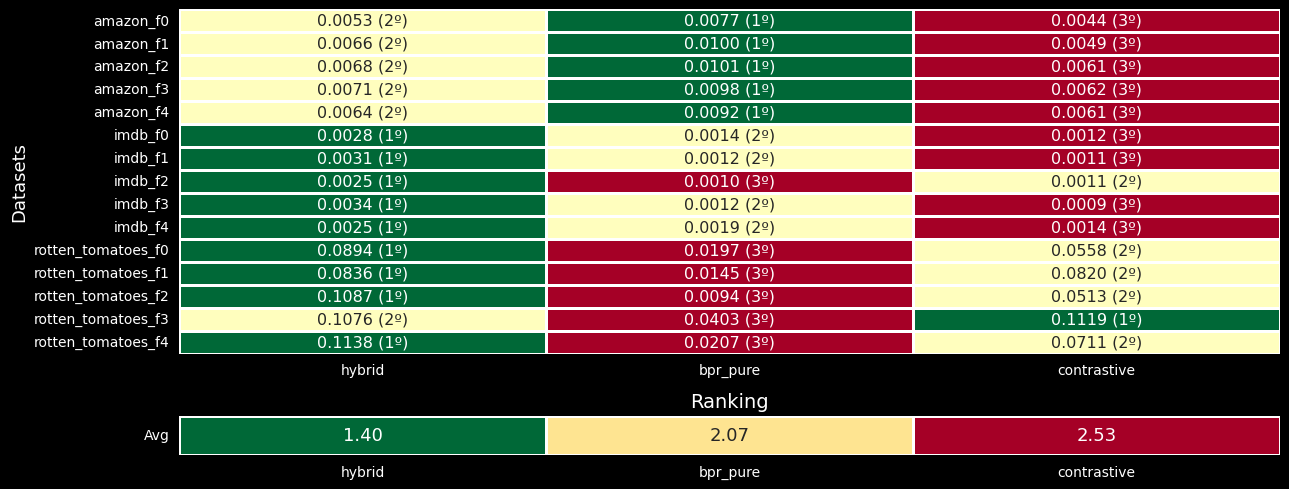

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Carregar e tratar os dados
df = pd.read_csv('tabela_final.csv')
df.columns = [col.strip().replace('\n', '') for col in df.columns]
df.set_index(df.columns[0], inplace=True)

def extract_rank(val):
    match = re.search(r'\((\d+)º\)', str(val))
    return int(match.group(1)) if match else 0

rank_df = df.apply(lambda col: col.map(extract_rank))

# 2. Calcular Ranking Médio e ordenar colunas (da melhor média para a pior)
ranking_medio = rank_df.mean().sort_values()
rank_df_ordenado = rank_df[ranking_medio.index]
df_ordenado = df[ranking_medio.index]

# Criar um DataFrame de uma linha para o segundo Heatmap (as médias)
mean_df = pd.DataFrame(ranking_medio).T
mean_df.index = ['Média Geral']

# 3. Plotagem
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5),
                               gridspec_kw={'height_ratios': [7, 0.8]})

# --- Heatmap 1: Detalhado ---
sns.heatmap(rank_df_ordenado, annot=df_ordenado.values, fmt="", cmap='RdYlGn_r',
            linewidths=0.8, ax=ax1, cbar=False, annot_kws={"size": 11.5}) # Cbar removido para limpar o visual
#ax1.set_title('Ranking Detalhado por Dataset', fontsize=16, pad=15)
ax1.set_ylabel('Datasets', fontsize=13)

# --- Heatmap 2: Média (Consolidado) ---
sns.heatmap(mean_df, annot=True, fmt=".2f", cmap='RdYlGn_r',
            linewidths=0.8, ax=ax2, cbar=False, annot_kws={"size": 13})
ax2.set_title('Ranking', fontsize=14)
ax2.set_yticklabels(['Avg'], rotation=0)

plt.tight_layout()
plt.savefig('heatmap_duplo_ranking.png', dpi=300)
plt.show()